In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Task 1: Creating the dataset (15 rows, 2 features, 1 target)
data = {
    'Study_Hours': [2, 3, 4, 5, 5.5, 6, 7, 7.5, 8, 8.5, 9, 9.5, 10, 3.5, 4.5],
    'Sleep_Hours': [8, 7, 6, 7, 8, 6, 7, 8, 5, 7, 8, 6, 8, 5, 6],
    'Exam_Score': [55, 60, 65, 72, 75, 78, 85, 88, 82, 90, 95, 92, 98, 62, 68]
}

df = pd.DataFrame(data)
print("Dataset created successfully!")

Dataset created successfully!


In [19]:
# First 5 rows
print("--- First 5 Rows ---")
print(df.head())

# Last 5 rows
print("\n--- Last 5 Rows ---")
print(df.tail())

# Dataset shape
print("\n--- Dataset Shape ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# Data types
print("\n--- Data Types ---")
print(df.dtypes)

# Check for missing values
print("\n--- Missing Values ---")
print(df.isnull().sum())

--- First 5 Rows ---
   Study_Hours  Sleep_Hours  Exam_Score
0          2.0            8          55
1          3.0            7          60
2          4.0            6          65
3          5.0            7          72
4          5.5            8          75

--- Last 5 Rows ---
    Study_Hours  Sleep_Hours  Exam_Score
10          9.0            8          95
11          9.5            6          92
12         10.0            8          98
13          3.5            5          62
14          4.5            6          68

--- Dataset Shape ---
Rows: 15, Columns: 3

--- Data Types ---
Study_Hours    float64
Sleep_Hours      int64
Exam_Score       int64
dtype: object

--- Missing Values ---
Study_Hours    0
Sleep_Hours    0
Exam_Score     0
dtype: int64


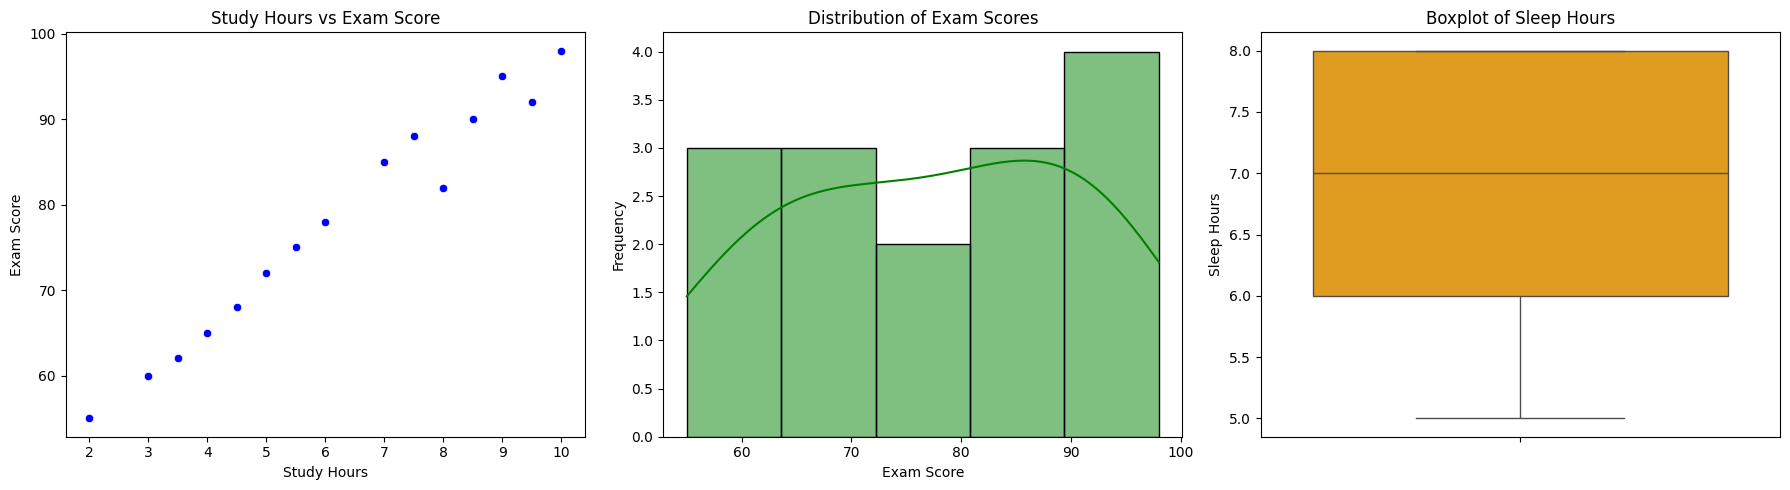

In [20]:
# Set up the figure space for 3 plots
plt.figure(figsize=(18, 5))

# 1. Scatter Plot: Study Hours vs Exam Score
plt.subplot(1, 3, 1)
sns.scatterplot(x='Study_Hours', y='Exam_Score', data=df, color='blue')
plt.title('Study Hours vs Exam Score')
plt.xlabel('Study Hours')
plt.ylabel('Exam Score')

# 2. Histogram: Distribution of Exam Scores
plt.subplot(1, 3, 2)
sns.histplot(df['Exam_Score'], bins=5, kde=True, color='green')
plt.title('Distribution of Exam Scores')
plt.xlabel('Exam Score')
plt.ylabel('Frequency')

# 3. Boxplot: Sleep Hours
plt.subplot(1, 3, 3)
sns.boxplot(y=df['Sleep_Hours'], color='orange')
plt.title('Boxplot of Sleep Hours')
plt.ylabel('Sleep Hours')

plt.tight_layout()
plt.show()

In [21]:
# Define features (X) and target (y)
X = df[['Study_Hours', 'Sleep_Hours']]
y = df['Exam_Score']

# Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R2 Score: {r2:.2f}")

Mean Absolute Error (MAE): 1.75
R2 Score: 0.98


In [22]:
# --- Experiment 1: Remove 'Sleep_Hours' ---
X_reduced = df[['Study_Hours']] # Only 1 feature
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reduced, y, test_size=0.2, random_state=42)

model_reduced = LinearRegression()
model_reduced.fit(X_train_r, y_train_r)
r2_reduced = r2_score(y_test_r, model_reduced.predict(X_test_r))

# --- Experiment 2: Add a new feature ('Previous_Score') ---
# Adding a new mock feature to our dataframe
df['Previous_Score'] = [50, 58, 60, 70, 72, 75, 80, 85, 80, 88, 92, 90, 95, 58, 65]

X_expanded = df[['Study_Hours', 'Sleep_Hours', 'Previous_Score']]
X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(X_expanded, y, test_size=0.2, random_state=42)

model_expanded = LinearRegression()
model_expanded.fit(X_train_e, y_train_e)
r2_expanded = r2_score(y_test_e, model_expanded.predict(X_test_e))

print(f"R2 Score (Original 2 Features): {r2:.2f}")
print(f"R2 Score (Removed Sleep_Hours): {r2_reduced:.2f}")
print(f"R2 Score (Added Previous_Score): {r2_expanded:.2f}")

R2 Score (Original 2 Features): 0.98
R2 Score (Removed Sleep_Hours): 0.98
R2 Score (Added Previous_Score): 1.00


In [23]:
# Train on the FULL dataset
model_full = LinearRegression()
model_full.fit(X, y) # Using the original X from Task 4

# Predict on the exact same data it trained on
y_pred_full = model_full.predict(X)
r2_full = r2_score(y, y_pred_full)

print(f"R2 Score (Proper Train/Test Split): {r2:.2f}")
print(f"R2 Score (Trained and Tested on Full Data): {r2_full:.2f}")

R2 Score (Proper Train/Test Split): 0.98
R2 Score (Trained and Tested on Full Data): 0.99
